In [1]:
# IT24103816_Data_Scaling.ipynb
# Min-Max Data Scaling Implementation for Financial Transaction Dataset

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

# Load the dataset
df = pd.read_csv('encoded_dataset.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (927049, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927049 entries, 0 to 927048
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            927049 non-null  int64  
 1   amount          927049 non-null  float64
 2   nameOrig        927049 non-null  object 
 3   oldbalanceOrg   927049 non-null  float64
 4   newbalanceOrig  927049 non-null  float64
 5   nameDest        927048 non-null  object 
 6   oldbalanceDest  927048 non-null  float64
 7   newbalanceDest  927048 non-null  float64
 8   isFraud         927048 non-null  float64
 9   isFlaggedFraud  927048 non-null  float64
 10  amount_capped   927049 non-null  float64
 11  amount_bin      927049 non-null  object 
 12  type_CASH_IN    927049 non-null  bool   
 13  type_CASH_OUT   927049 non-null  bool   
 14  type_DEBIT      927049 non-null  bool   
 15  type_PAYMENT    927049 non-null  bool   
 16  type_TRANSFER

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_capped,amount_bin,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_cash
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,Medium,False,False,False,True,False,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,Medium,False,False,False,True,False,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,Small,False,False,False,False,True,0
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,Small,False,True,False,False,False,1
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,Medium,False,False,False,True,False,0


In [2]:
# Select numerical columns for Min-Max scaling
numerical_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                  'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'amount_capped']

print("Numerical columns selected for Min-Max scaling:")
print(numerical_cols)

print("\nSummary Statistics before scaling:")
print(df[numerical_cols].describe())

Numerical columns selected for Min-Max scaling:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'amount_capped']

Summary Statistics before scaling:
                step        amount  oldbalanceOrg  newbalanceOrig  \
count  927049.000000  9.270490e+05   9.270490e+05    9.270490e+05   
mean       23.676547  1.627395e+05   8.842787e+05    9.050586e+05   
std        11.942196  2.620741e+05   2.999742e+06    3.036590e+06   
min         1.000000  1.000000e-01   0.000000e+00    0.000000e+00   
25%        14.000000  1.306330e+04   0.000000e+00    0.000000e+00   
50%        19.000000  8.107067e+04   1.614000e+04    0.000000e+00   
75%        36.000000  2.200785e+05   1.444130e+05    1.852935e+05   
max        43.000000  1.000000e+07   3.893942e+07    3.894623e+07   

       oldbalanceDest  newbalanceDest        isFraud  isFlaggedFraud  \
count    9.270480e+05    9.270480e+05  927048.000000        927048.0   
mean     9.879

In [3]:
# Apply Min-Max Scaling
minmax_scaler = MinMaxScaler()

# Create a copy of the dataframe for scaled data
df_scaled = df.copy()

# Apply Min-Max scaling to numerical columns
df_scaled[numerical_cols] = minmax_scaler.fit_transform(df_scaled[numerical_cols])

print("Min-Max Scaled Data - First 5 rows:")
print(df_scaled[numerical_cols].head())

print("\nSummary Statistics after Min-Max Scaling:")
print(df_scaled[numerical_cols].describe())

Min-Max Scaled Data - First 5 rows:
   step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0   0.0  0.000984       0.004369        0.004116        0.000000   
1   0.0  0.000186       0.000546        0.000498        0.000000   
2   0.0  0.000018       0.000005        0.000000        0.000000   
3   0.0  0.000018       0.000005        0.000000        0.000511   
4   0.0  0.001167       0.001067        0.000767        0.000000   

   newbalanceDest  isFraud  isFlaggedFraud  amount_capped  
0             0.0      0.0             0.0       0.018544  
1             0.0      0.0             0.0       0.003513  
2             0.0      1.0             0.0       0.000341  
3             0.0      1.0             0.0       0.000341  
4             0.0      0.0             0.0       0.021990  

Summary Statistics after Min-Max Scaling:
                step         amount  oldbalanceOrg  newbalanceOrig  \
count  927049.000000  927049.000000  927049.000000   927049.000000   
mean        

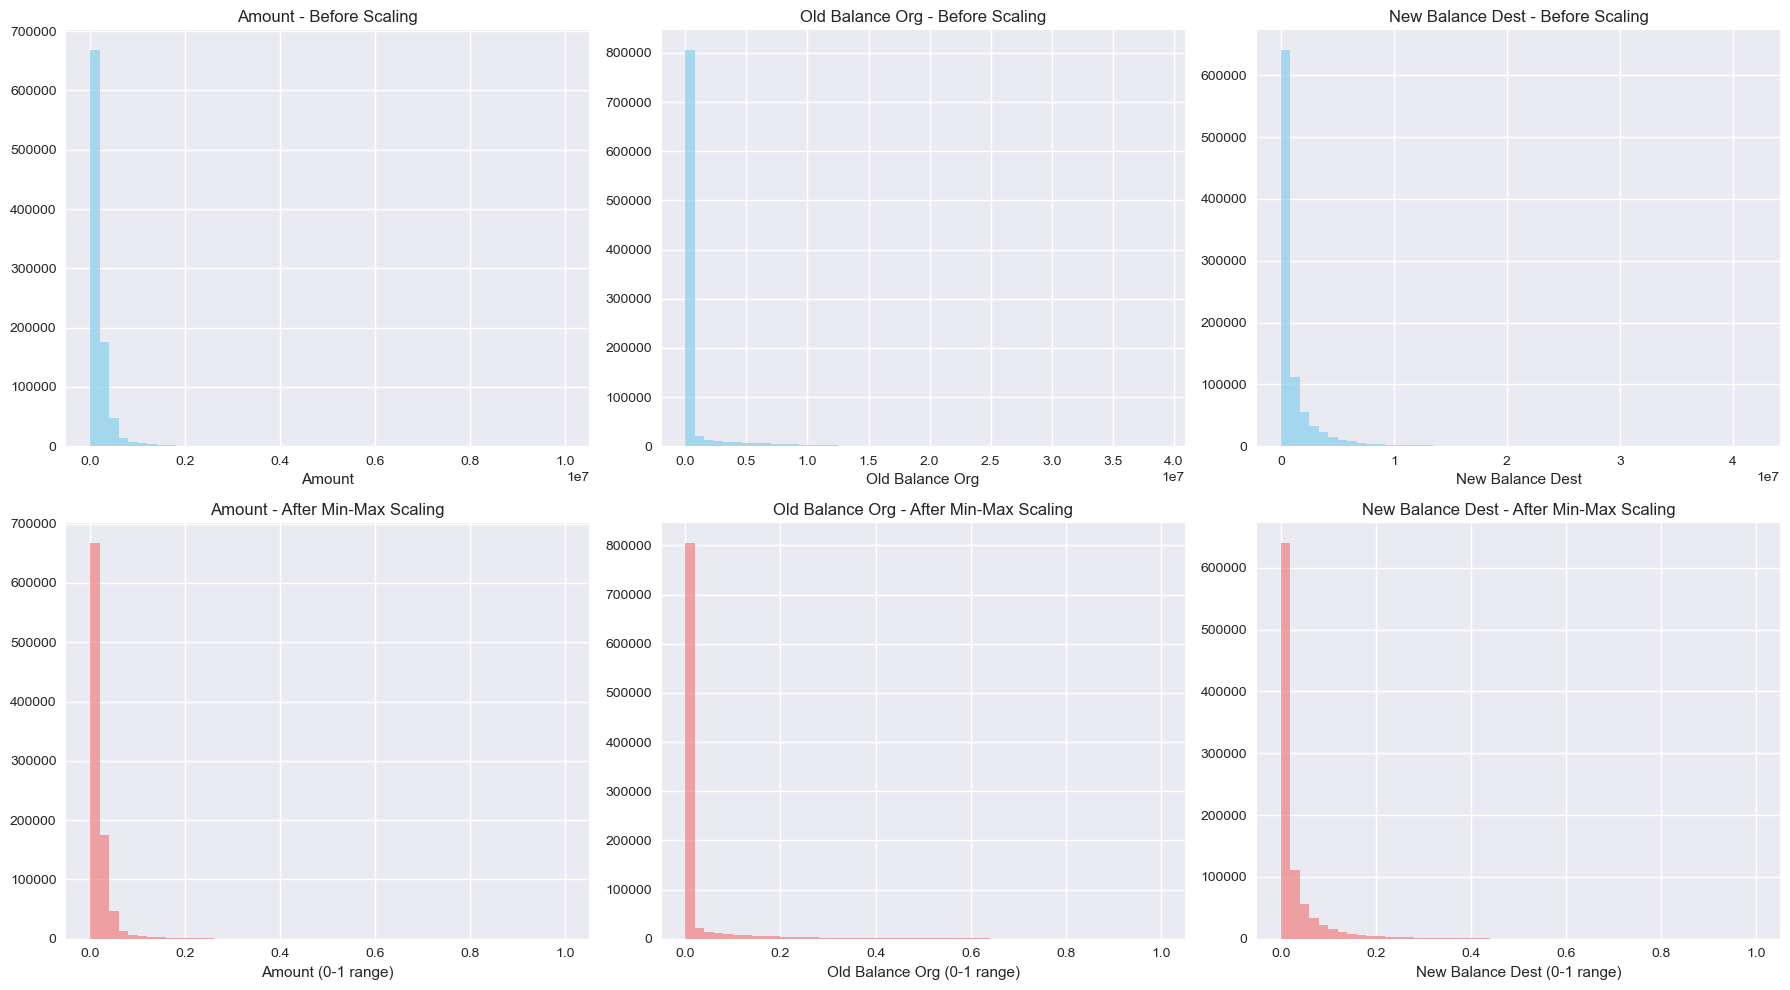

In [4]:
# Visualize the effect of Min-Max scaling on key features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Amount - Before and After
df['amount'].hist(bins=50, ax=axes[0,0], alpha=0.7, color='skyblue')
axes[0,0].set_title('Amount - Before Scaling')
axes[0,0].set_xlabel('Amount')

df_scaled['amount'].hist(bins=50, ax=axes[1,0], alpha=0.7, color='lightcoral')
axes[1,0].set_title('Amount - After Min-Max Scaling')
axes[1,0].set_xlabel('Amount (0-1 range)')

# Old Balance Org - Before and After
df['oldbalanceOrg'].hist(bins=50, ax=axes[0,1], alpha=0.7, color='skyblue')
axes[0,1].set_title('Old Balance Org - Before Scaling')
axes[0,1].set_xlabel('Old Balance Org')

df_scaled['oldbalanceOrg'].hist(bins=50, ax=axes[1,1], alpha=0.7, color='lightcoral')
axes[1,1].set_title('Old Balance Org - After Min-Max Scaling')
axes[1,1].set_xlabel('Old Balance Org (0-1 range)')

# New Balance Dest - Before and After
df['newbalanceDest'].hist(bins=50, ax=axes[0,2], alpha=0.7, color='skyblue')
axes[0,2].set_title('New Balance Dest - Before Scaling')
axes[0,2].set_xlabel('New Balance Dest')

df_scaled['newbalanceDest'].hist(bins=50, ax=axes[1,2], alpha=0.7, color='lightcoral')
axes[1,2].set_title('New Balance Dest - After Min-Max Scaling')
axes[1,2].set_xlabel('New Balance Dest (0-1 range)')

plt.tight_layout()
plt.show()

In [5]:
# Verify Min-Max scaling results
print("Verifying Min-Max Scaling Results:")
print("All values should be in the range [0, 1]")
print("-" * 50)

for col in numerical_cols:
    min_val = df_scaled[col].min()
    max_val = df_scaled[col].max()
    print(f"{col:15} -> Min: {min_val:.4f}, Max: {max_val:.4f}, Range: [{min_val:.4f}, {max_val:.4f}]")

Verifying Min-Max Scaling Results:
All values should be in the range [0, 1]
--------------------------------------------------
step            -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]
amount          -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]
oldbalanceOrg   -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]
newbalanceOrig  -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]
oldbalanceDest  -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]
newbalanceDest  -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]
isFraud         -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]
isFlaggedFraud  -> Min: 0.0000, Max: 0.0000, Range: [0.0000, 0.0000]
amount_capped   -> Min: 0.0000, Max: 1.0000, Range: [0.0000, 1.0000]


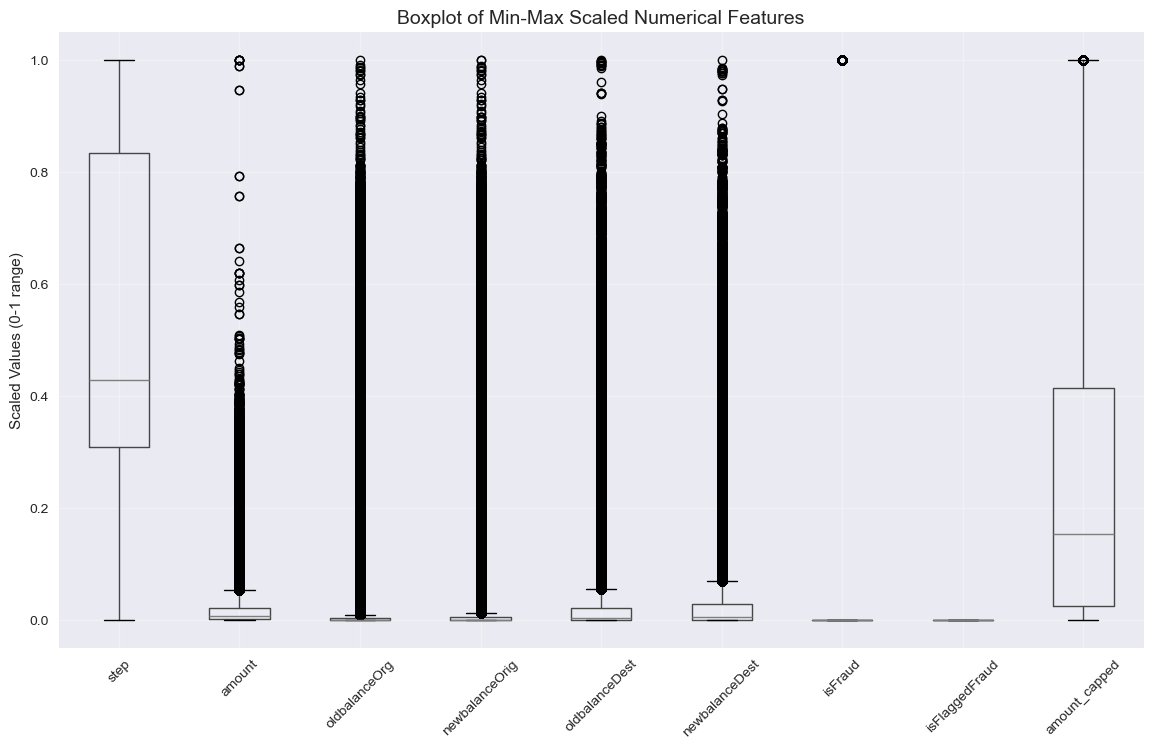

In [11]:
# Boxplots for Min-Max Scaled Features
plt.figure(figsize=(14, 8))

# Boxplot for all scaled numerical features
df_scaled[numerical_cols].boxplot()
plt.title('Boxplot of Min-Max Scaled Numerical Features', fontsize=14)
plt.ylabel('Scaled Values (0-1 range)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

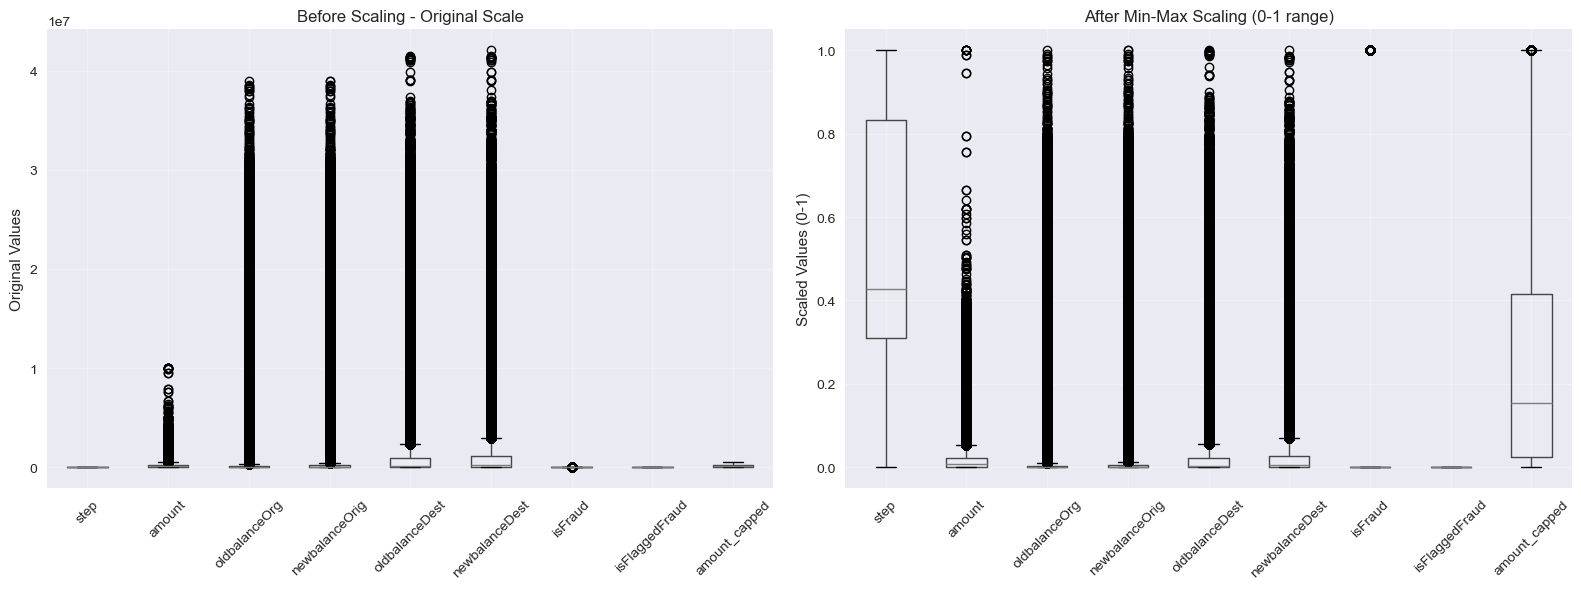

In [13]:
# Comparative Boxplots: Before vs After Scaling
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before scaling boxplot
df[numerical_cols].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling - Original Scale')
axes[0].set_ylabel('Original Values')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# After Min-Max scaling boxplot
df_scaled[numerical_cols].boxplot(ax=axes[1])
axes[1].set_title('After Min-Max Scaling (0-1 range)')
axes[1].set_ylabel('Scaled Values (0-1)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

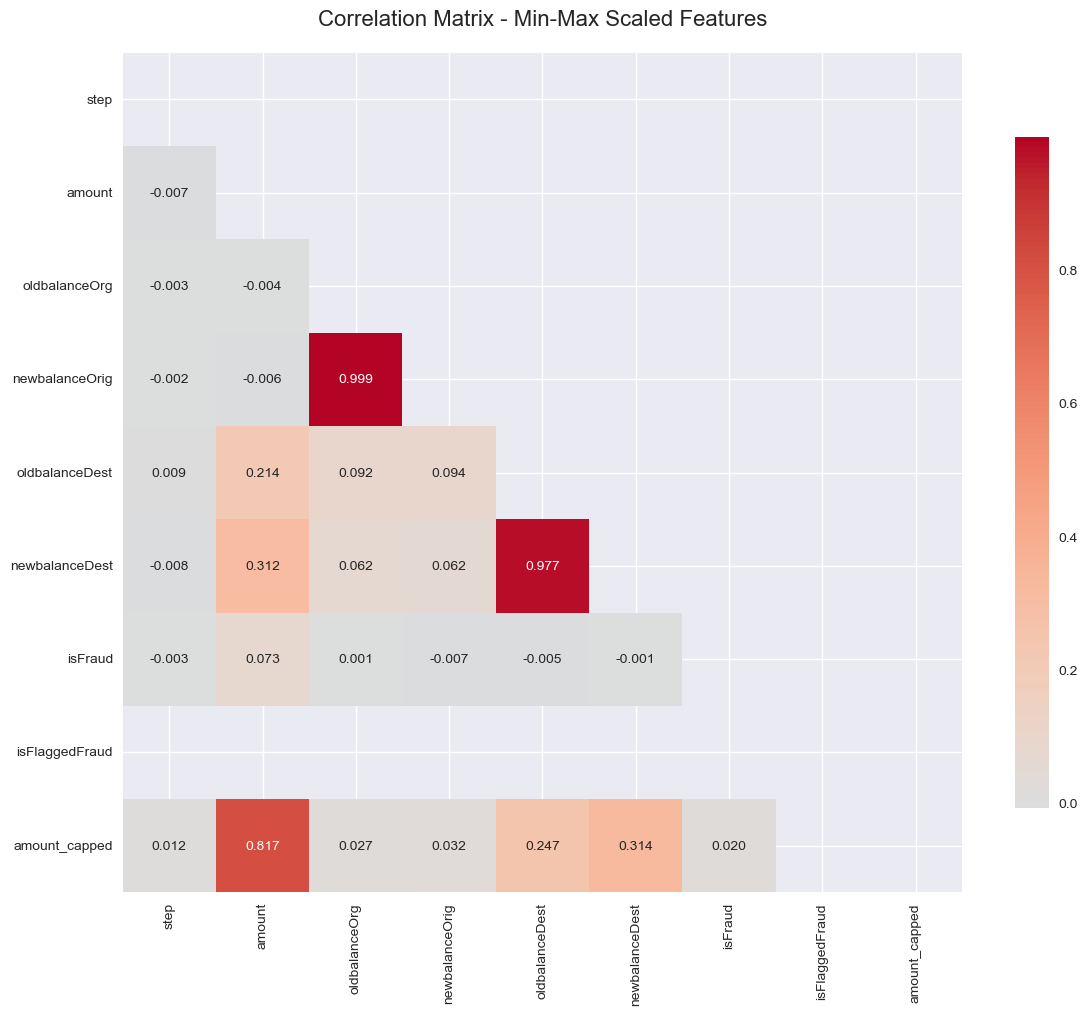

In [14]:
# Correlation Matrix for Scaled Features
plt.figure(figsize=(12, 10))

# Calculate correlation matrix
correlation_matrix = df_scaled[numerical_cols].corr()

# Create heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix - Min-Max Scaled Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

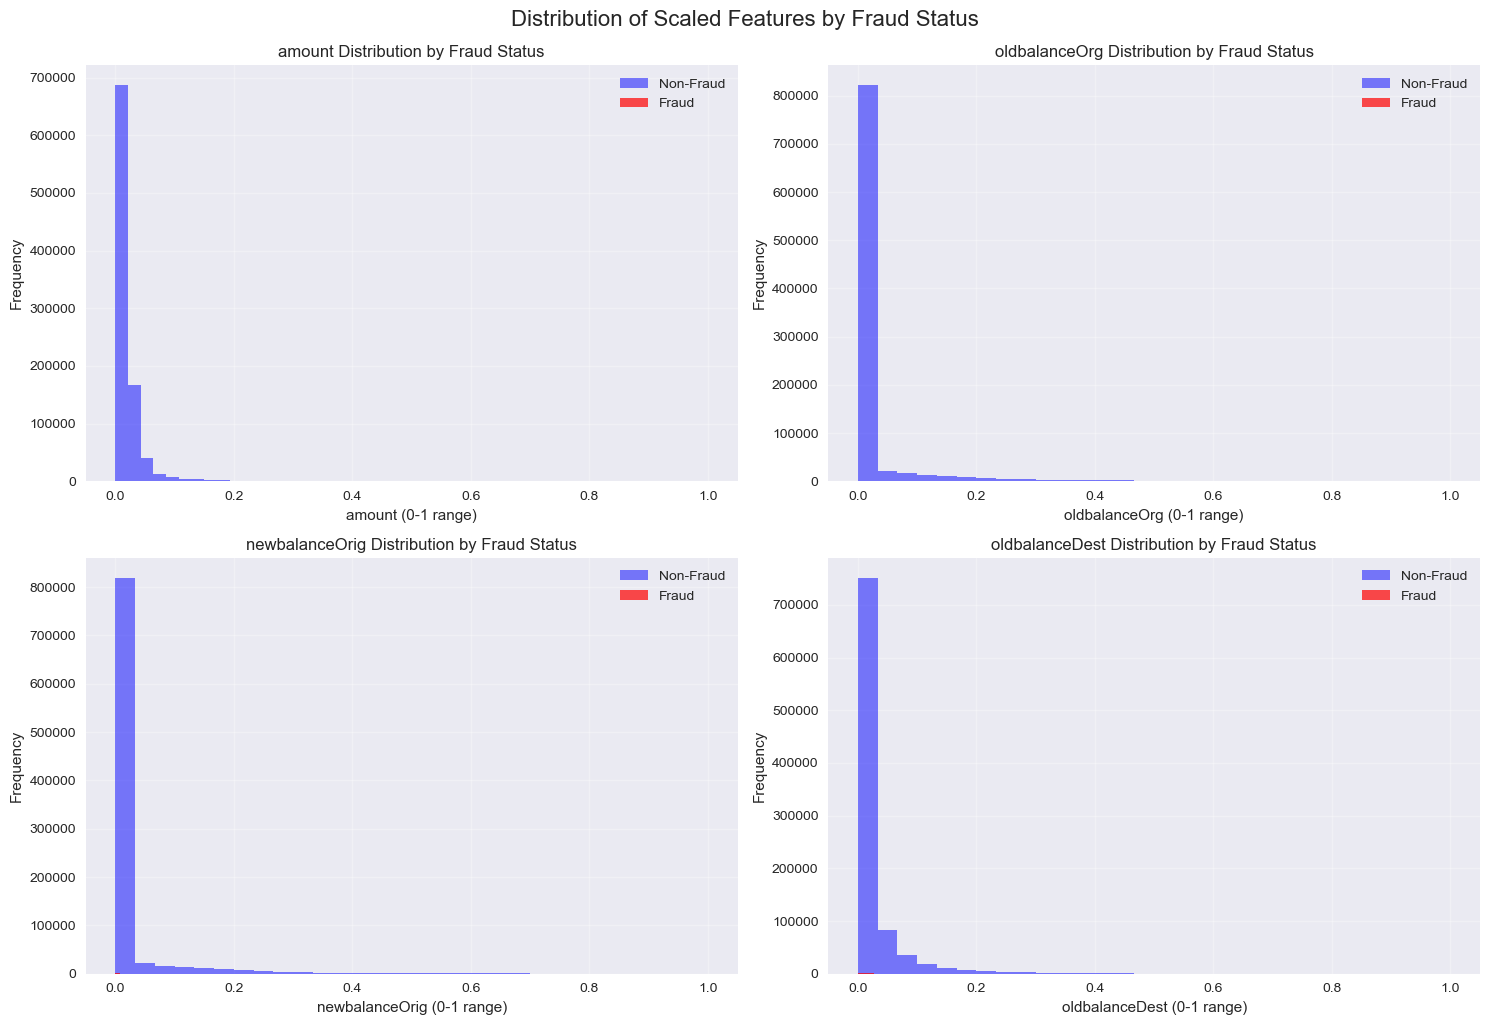

In [29]:
# Distribution of scaled features by fraud status
fraud_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(fraud_features):
    # Separate fraud and non-fraud transactions
    fraud_data = df_scaled[df_scaled['isFraud'] == 1][feature]
    non_fraud_data = df_scaled[df_scaled['isFraud'] == 0][feature]
    
    # Plot histograms
    axes[i].hist(non_fraud_data, bins=30, alpha=0.5, label='Non-Fraud', color='blue')
    axes[i].hist(fraud_data, bins=30, alpha=0.7, label='Fraud', color='red')
    axes[i].set_title(f'{feature} Distribution by Fraud Status')
    axes[i].set_xlabel(f'{feature} (0-1 range)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of Scaled Features by Fraud Status', y=1.02, fontsize=16)
plt.show()

In [30]:
# Display scaler information
print("\nMin-Max Scaler Information:")
print("Feature range:", minmax_scaler.feature_range)
print("\nData minimum per feature (original scale):")
for i, col in enumerate(numerical_cols):
    print(f"{col:15}: {minmax_scaler.data_min_[i]:.2f}")

print("\nData maximum per feature (original scale):")
for i, col in enumerate(numerical_cols):
    print(f"{col:15}: {minmax_scaler.data_max_[i]:.2f}")


Min-Max Scaler Information:
Feature range: (0, 1)

Data minimum per feature (original scale):
step           : 1.00
amount         : 0.10
oldbalanceOrg  : 0.00
newbalanceOrig : 0.00
oldbalanceDest : 0.00
newbalanceDest : 0.00
isFraud        : 0.00
isFlaggedFraud : 0.00
amount_capped  : 0.10

Data maximum per feature (original scale):
step           : 43.00
amount         : 10000000.00
oldbalanceOrg  : 38939424.03
newbalanceOrig : 38946233.02
oldbalanceDest : 41482697.12
newbalanceDest : 42054659.73
isFraud        : 1.00
isFlaggedFraud : 0.00
amount_capped  : 530601.28


In [32]:
# Save the Min-Max scaled dataset
df_scaled.to_csv('Scaled_dataset.csv', index=False)
print("Min-Max scaled dataset saved as 'minmax_scaled_dataset.csv'")

# Display final dataset info
print(f"\nFinal dataset shape: {df_scaled.shape}")
print("\nFirst 3 rows of scaled data:")
print(df_scaled[numerical_cols].head(3))

Min-Max scaled dataset saved as 'minmax_scaled_dataset.csv'

Final dataset shape: (927049, 18)

First 3 rows of scaled data:
   step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0   0.0  0.000984       0.004369        0.004116             0.0   
1   0.0  0.000186       0.000546        0.000498             0.0   
2   0.0  0.000018       0.000005        0.000000             0.0   

   newbalanceDest  isFraud  isFlaggedFraud  amount_capped  
0             0.0      0.0             0.0       0.018544  
1             0.0      0.0             0.0       0.003513  
2             0.0      1.0             0.0       0.000341  
